# Credit Card Approval Prediction — ML Pipeline

**Goal:** Predict whether a credit card applicant should be approved (good credit risk) or rejected (bad credit risk).

**Dataset:** Kaggle — "Credit Card Approval Prediction" by rikdifos
https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction

Download `application_record.csv` and `credit_record.csv` from Kaggle first. This notebook is set up for **Google Colab** — run the upload cell in Section 2 to bring in your CSVs (or, if running locally in Jupyter, just place both CSVs in the same folder as this notebook).

**Pipeline stages:**
1. Upload / load data
2. Engineer target label from credit history
3. Exploratory Data Analysis (EDA)
4. Preprocessing (missing values, encoding, scaling)
5. Handle class imbalance
6. Train baseline + advanced models
7. Evaluate with appropriate metrics
8. Feature importance & conclusions


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)

# Optional: pip install imbalanced-learn xgboost
# from imblearn.over_sampling import SMOTE
# from xgboost import XGBClassifier

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')


## 2. Upload Dataset (Google Colab)

Run the cell below — it will pop up a file picker. Select **both** `application_record.csv` and `credit_record.csv` from your computer (the ones you downloaded and unzipped from Kaggle).

If you're running this locally in Jupyter instead of Colab, skip this cell and just make sure both CSVs are in the same folder as this notebook.


In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()  # pick application_record.csv and credit_record.csv when prompted
except ImportError:
    print("Not running in Colab — skipping upload widget. Make sure both CSVs are in this folder.")


Saving credit_record.csv to credit_record.csv
Saving application_record.csv to application_record.csv


## 3. Load Data

In [ ]:
app = pd.read_csv('application_record.csv')
credit = pd.read_csv('credit_record.csv')

print('Application record shape:', app.shape)
print('Credit record shape:', credit.shape)

app.head()


Application record shape: (438557, 18)
Credit record shape: (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
credit.head()


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


## 4. Engineer the Target Label

`credit_record.csv` has a `STATUS` column per applicant per month:
- `0`: 1-29 days past due
- `1`: 30-59 days past due
- `2`: 60-89 days past due
- `3`: 90-119 days past due
- `4`: 120-149 days past due
- `5`: overdue or bad debt, write-off for more than 150 days
- `C`: paid off that month
- `X`: no loan for that month

Common approach: label an applicant as **bad (1)** if they were ever 60+ days overdue (STATUS in 2,3,4,5), else **good (0)**.


In [ ]:
def label_bad(status_series):
    bad_statuses = {'2', '3', '4', '5'}
    return int(status_series.isin(bad_statuses).any())

credit['STATUS'] = credit['STATUS'].astype(str)
target = credit.groupby('ID')['STATUS'].apply(label_bad).reset_index()
target.columns = ['ID', 'TARGET']

print(target['TARGET'].value_counts(normalize=True))
target.head()


TARGET
0    0.985495
1    0.014505
Name: proportion, dtype: float64


,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [ ]:
df = app.merge(target, on='ID', how='inner')
print('Merged shape:', df.shape)
df.head()


Merged shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## 5. Exploratory Data Analysis (EDA)

Check missing values, class balance, and key feature distributions before doing anything else.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [ ]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
OCCUPATION_TYPE    11323
dtype: int64


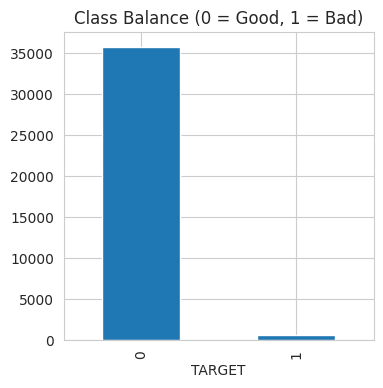

TARGET
0    0.983103
1    0.016897
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(4,4))
df['TARGET'].value_counts().plot(kind='bar')
plt.title('Class Balance (0 = Good, 1 = Bad)')
plt.show()

print(df['TARGET'].value_counts(normalize=True))


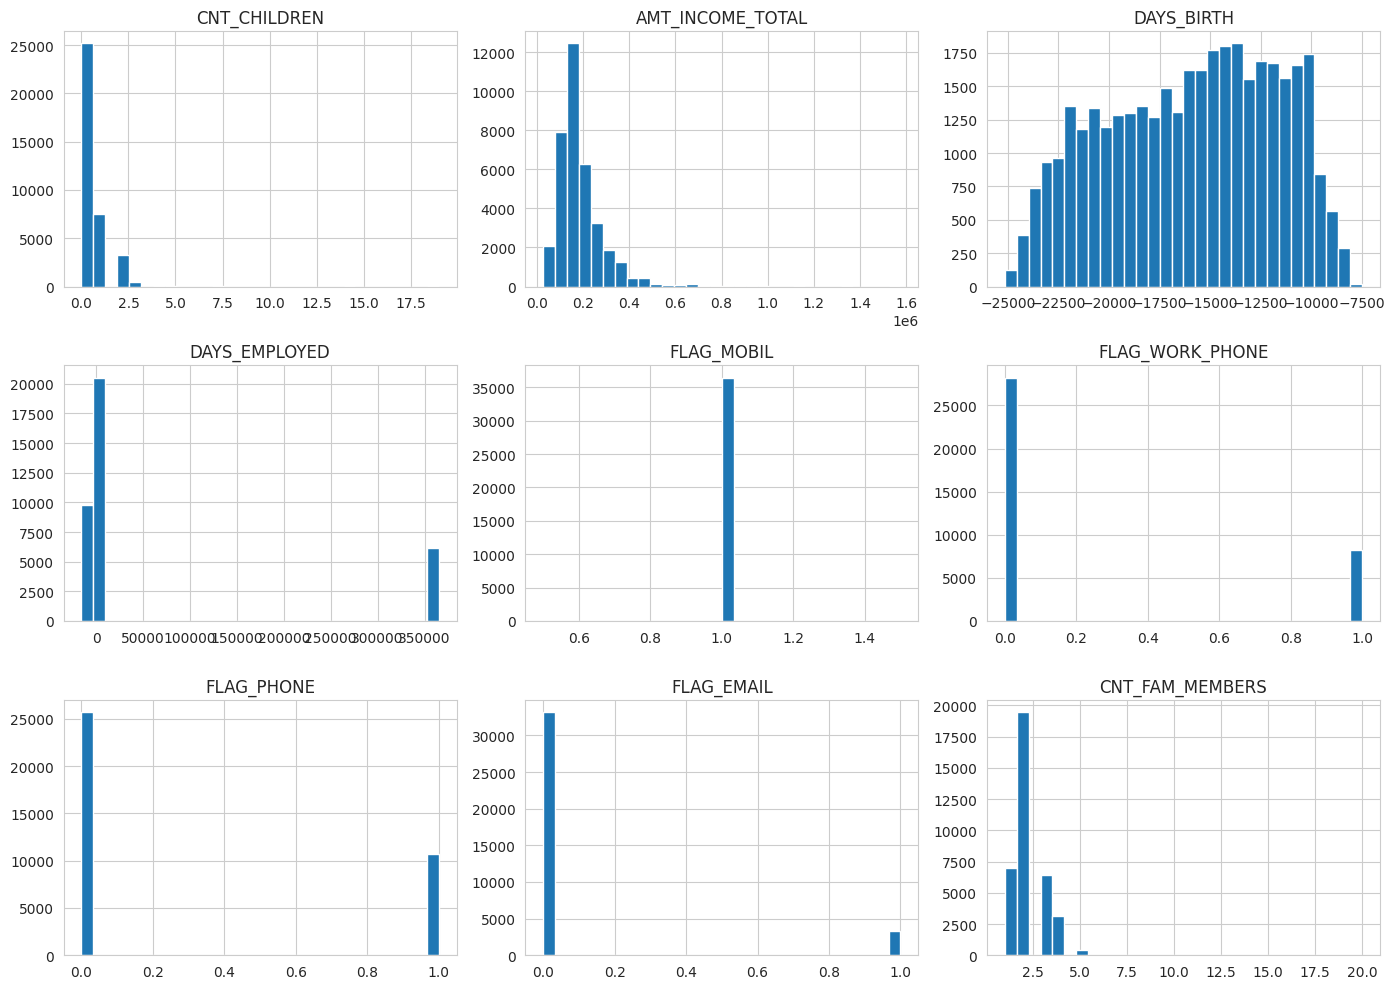

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['ID', 'TARGET']]

df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', categorical_cols)

for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())


Categorical columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

CODE_GENDER:
CODE_GENDER
F    24430
M    12027
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
N    22614
Y    13843
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    24506
N    11951
Name: count, dtype: int64

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64

NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64

NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Married                 25048
Single / not married     4829
Civil marriage  

## 6. Feature Engineering

Raw columns like `DAYS_BIRTH` and `DAYS_EMPLOYED` are negative day counts — convert to more usable units.


In [ ]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
# DAYS_EMPLOYED has a known placeholder value (365243) meaning 'not currently employed'
df['IS_EMPLOYED'] = (df['DAYS_EMPLOYED'] < 0).astype(int)
df['YEARS_EMPLOYED'] = np.where(df['DAYS_EMPLOYED'] < 0, -df['DAYS_EMPLOYED'] / 365, 0)

df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

df.head()


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE_YEARS,IS_EMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,0,32,1,12.443836
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,NaN,2.0,0,32,1,12.443836
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,1,3.106849
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,1,8.358904
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,1,8.358904


## 7. Train/Test Split

In [ ]:
X = df.drop(columns=['ID', 'TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (29165, 18)  Test shape: (7292, 18)


## 8. Preprocessing Pipeline

Numeric features get scaled, categorical features get one-hot encoded. Wrapped in a `ColumnTransformer` so it plugs directly into any sklearn model.


In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## 9. Baseline Model — Logistic Regression

Note: this dataset is usually heavily imbalanced (few 'bad' cases), so `class_weight='balanced'` matters more than accuracy here.


In [ ]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_lr))


              precision    recall  f1-score   support

           0       0.99      0.62      0.76      7169
           1       0.02      0.48      0.04       123

    accuracy                           0.62      7292
   macro avg       0.50      0.55      0.40      7292
weighted avg       0.97      0.62      0.75      7292

ROC-AUC: 0.5661316168190277


## 10. Advanced Model — Random Forest

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.99      0.96      0.97      7169
           1       0.10      0.28      0.14       123

    accuracy                           0.94      7292
   macro avg       0.54      0.62      0.56      7292
weighted avg       0.97      0.94      0.96      7292

ROC-AUC: 0.6622171794322211


## 11. Model Comparison & Evaluation

Since classes are imbalanced, prioritize **ROC-AUC**, **precision/recall**, and **F1** over raw accuracy.


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)]
})
results


,Model,ROC-AUC,F1 Score
0,Logistic Regression,0.566132,0.040508
1,Random Forest,0.662217,0.142857


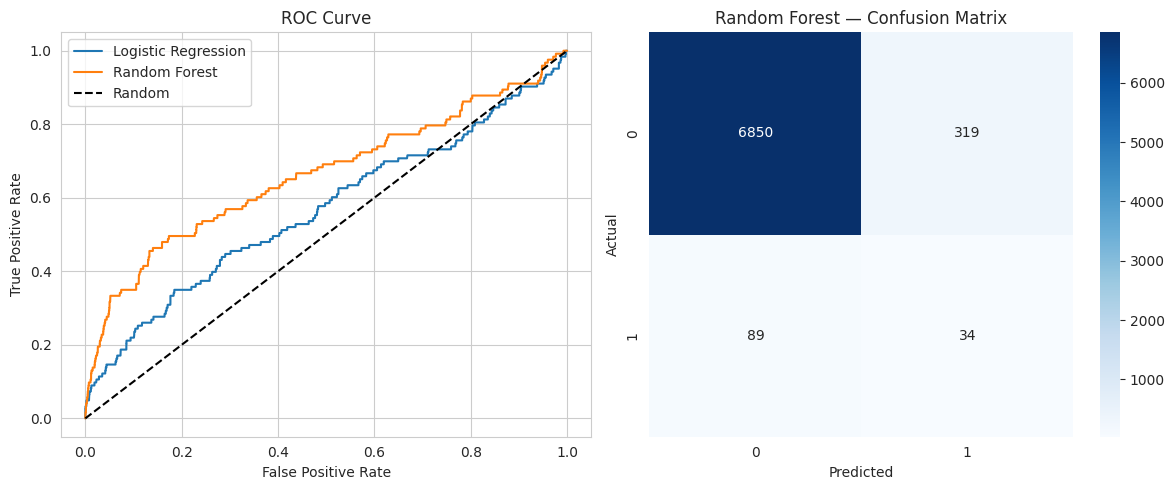

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, y_proba in [('Logistic Regression', y_proba_lr), ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 12. Feature Importance

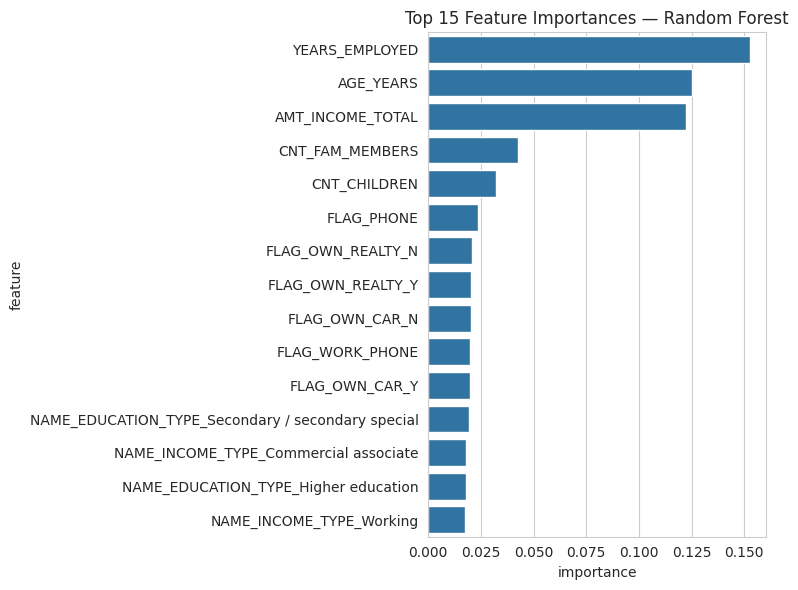

In [ ]:
# ===========================
# 12. Feature Importance
# ===========================

feature_names = (
    numeric_features +
    list(
        rf_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features)
    )
)

importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(
    by='importance',
    ascending=False
).head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp,
    x='importance',
    y='feature'
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# ===========================
# 13. Save Trained Model
# ===========================

import joblib

joblib.dump(rf_pipeline, "credit_card_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("credit_card_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>